# EVT Threshold Analysis

**Depends on:** `01_time_series_modeling.ipynb`, which must be run first -- it produces `standardized_residuals.csv` (the t-GARCH standardized residuals used below) in this same `notebooks/` folder.

This notebook fits a Generalized Pareto Distribution (GPD) to the left tail of those residuals via Peaks-Over-Threshold (POT). We need to be a bit careful here: we're interested in extreme *drops* in price, so the left tail. Three threshold-selection approaches are compared: a preliminary 0.01-quantile threshold, a mean-excess-plot selector, and a double-bootstrap AMSE ("Weissman-style") selector.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto

sns.set(style="whitegrid")

# ---------------------------------------------------------------------------
# Sign convention used throughout this notebook: standardized residuals and
# every derived threshold/quantile are signed so the LEFT tail (large
# losses / market crashes) is NEGATIVE. A GPD-based quantile like z_99 is
# the value below which the worst 1% of standardized residuals fall (a
# negative number); return-scale VaR = mu_hat + sigma_hat * z_q is
# therefore also negative and represents a loss.
# ---------------------------------------------------------------------------


In [2]:
df = pd.read_csv('standardized_residuals.csv', parse_dates=['Date'])
standardized_residuals_t = df['t Standardized Residuals']

garch_params = pd.read_csv('garch_params.csv').iloc[0]
mu_hat = garch_params['Mu']                    # log-return scale
sigma_hat_next = garch_params['Sigma_Hat_Next']  # one-step-ahead forecast, log-return scale
sigma_hat_avg = garch_params['Sigma_Hat_Avg']    # mean realized in-sample volatility, log-return scale
nu_hat = garch_params['Nu']

df.head()


,Date,Close,t Standardized Residuals,Conditional Volatility,Mu
0,1985-01-03,164.570007,-0.711809,0.007887,0.000764
1,1985-01-04,163.679993,-0.797717,0.007756,0.000764
2,1985-01-07,164.240005,0.345256,0.007679,0.000764
3,1985-01-08,163.990005,-0.308668,0.007412,0.000764
4,1985-01-09,165.179993,0.904156,0.007151,0.000764


In [3]:
# ---------------------------------------------------------------------------
# General VaR helpers, needed starting with the preliminary threshold below.
# ---------------------------------------------------------------------------

def gpd_var(u, xi, beta, q_u, p):
    """POT/GPD-based standardized-residual quantile z_p at confidence level
    p, given a GPD fit (u, xi, beta) with empirical exceedance rate
    q_u = P(X < u). Valid only when the requested tail probability (1-p)
    does not exceed q_u -- asking for a less extreme quantile than the
    threshold itself sits outside the region the GPD tail was actually fit
    to, so the extrapolation is not meaningful there."""
    if (1 - p) > q_u:
        raise ValueError(
            f"VaR at p={p} needs tail probability {1 - p:.4f}, which "
            f"exceeds this threshold's empirical exceedance rate "
            f"q_u={q_u:.4f} -- the GPD tail approximation is not valid at "
            f"this confidence level."
        )
    return u - (beta / xi) * (((1 - q_u) / (1 - p)) ** xi - 1)


def devolatilized_var(z_q, mu_hat, sigma_hat):
    """Convert a standardized-residual quantile z_q to an actual
    return-scale VaR: VaR = mu_hat + sigma_hat * z_q."""
    return mu_hat + sigma_hat * z_q


def gpd_xi_ci(xi_hat, n_exc, z=1.96):
    """Asymptotic standard-error-based CI for the GPD shape MLE (Smith
    1987): Var(xi_hat) ~= (1 + xi_hat)^2 / n_exc for large n_exc."""
    se = (1 + xi_hat) / np.sqrt(n_exc)
    return xi_hat - z * se, xi_hat + z * se, se


In [4]:
data = df[["Date", "t Standardized Residuals"]].dropna()
data["Residuals"] = -data["t Standardized Residuals"]
data = data.drop(columns=["t Standardized Residuals"])

In [5]:
data.head()

,Date,Residuals
0,1985-01-03,0.711809
1,1985-01-04,0.797717
2,1985-01-07,-0.345256
3,1985-01-08,0.308668
4,1985-01-09,-0.904156


# PEAK OVER THRESHOLD 

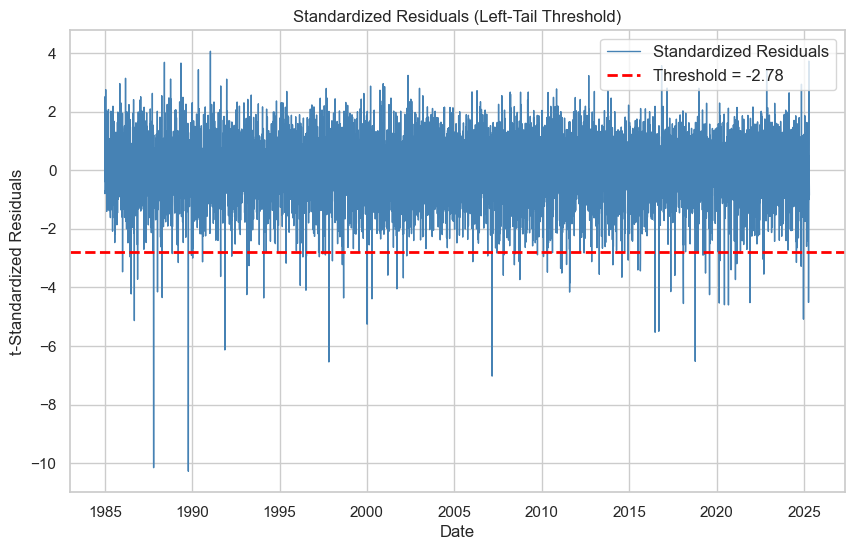

In [6]:
plt.figure(figsize=(10, 6))

threshold = standardized_residuals_t.quantile(0.01) #threshold

plt.plot(data["Date"], standardized_residuals_t, color='steelblue', lw=1, label='Standardized Residuals')


plt.axhline(y=threshold, color='red', linestyle='--', lw=2, label=f'Threshold = {threshold:.2f}')

plt.title("Standardized Residuals (Left-Tail Threshold)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.ylabel("t-Standardized Residuals", fontsize=12)
plt.legend(fontsize=12, loc='upper right')


plt.show()

In [7]:
threshold

-2.7830752444208073

In [8]:
exceedances = threshold - standardized_residuals_t[standardized_residuals_t < threshold] #again left tail

In [9]:
shape, loc, scale = genpareto.fit(exceedances, floc=0)

print(f"Threshold (u): {threshold:.4f}")
print(f"Shape (ξ): {shape:.4f}")
print(f"Scale (β): {scale:.4f}")

Threshold (u): -2.7831
Shape (ξ): 0.2561
Scale (β): 0.7334


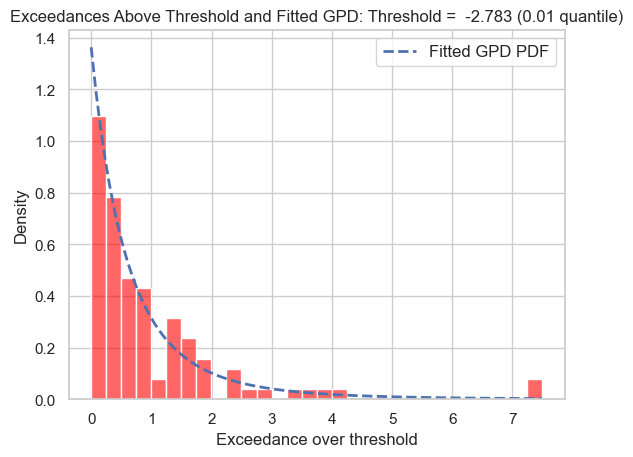

In [10]:

#exceedances above threshold plot


x = np.linspace(0, exceedances.max(), 100)
pdf = genpareto.pdf(x, c=shape, loc=0, scale=scale)

g = sns.histplot(exceedances, bins=30, kde=False, stat="density", color='red', alpha = 0.6)


g.plot(x, pdf, 'b--', lw=2, label='Fitted GPD PDF')


g.set(title="Exceedances Above Threshold and Fitted GPD: Threshold =  -2.783 (0.01 quantile)",
      xlabel="Exceedance over threshold", ylabel="Density")


g.legend(fontsize=12, loc='upper right')


plt.show()

VaR (95%) skipped for the preliminary threshold: VaR at p=0.95 needs tail probability 0.0500, which exceeds this threshold's empirical exceedance rate q_u=0.0100 -- the GPD tail approximation is not valid at this confidence level.


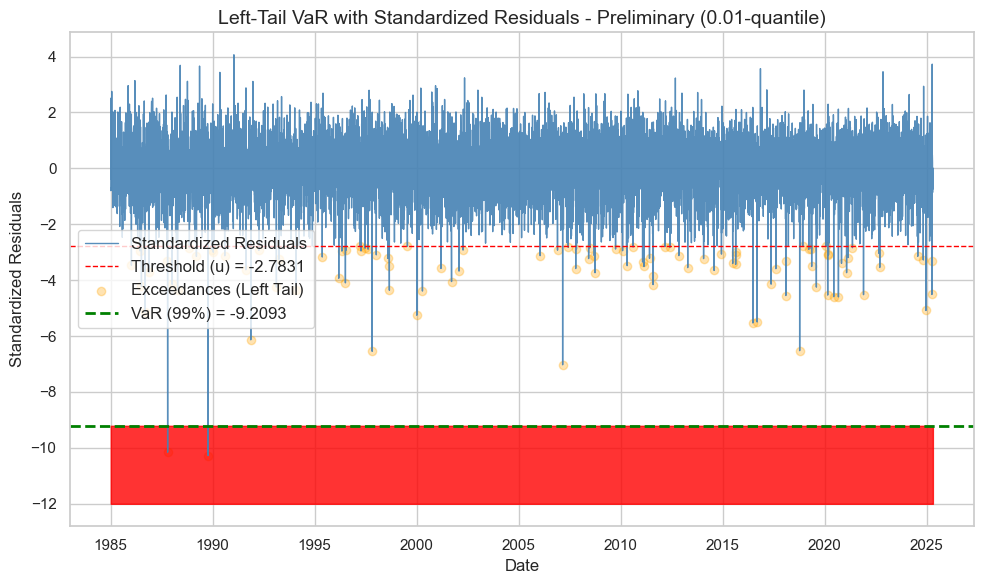

In [11]:
threshold_u_prelim = threshold
xi_prelim = shape
beta_prelim = scale
q_u_prelim = (standardized_residuals_t < threshold_u_prelim).sum() / standardized_residuals_t.notna().sum()

z_99_prelim = gpd_var(threshold_u_prelim, xi_prelim, beta_prelim, q_u_prelim, 0.99)
try:
    z_95_prelim = gpd_var(threshold_u_prelim, xi_prelim, beta_prelim, q_u_prelim, 0.95)
except ValueError as e:
    print(f"VaR (95%) skipped for the preliminary threshold: {e}")
    z_95_prelim = np.nan

plt.figure(figsize=(10, 6))

plt.plot(data['Date'], standardized_residuals_t, color='steelblue', label='Standardized Residuals', lw=1, alpha=0.9)

plt.axhline(y=threshold_u_prelim, color='red', linestyle='--', lw=1, label=f'Threshold (u) = {threshold_u_prelim:.4f}')

exceed_points = standardized_residuals_t[standardized_residuals_t < threshold_u_prelim]
plt.scatter(data['Date'][standardized_residuals_t < threshold_u_prelim], exceed_points, color='orange', label='Exceedances (Left Tail)', alpha=0.3)

plt.axhline(y=z_99_prelim, color='green', linestyle='--', lw=2, label=f'VaR (99%) = {z_99_prelim:.4f}')
plt.fill_between(data['Date'], y1=z_99_prelim, y2=-12, color='red', alpha=0.8)
if np.isfinite(z_95_prelim):
    plt.axhline(y=z_95_prelim, color='green', linestyle='--', lw=2, label=f'VaR (95%) = {z_95_prelim:.4f}')
    plt.fill_between(data['Date'], y1=z_95_prelim, y2=-12, color='orange', alpha=0.3)

plt.title('Left-Tail VaR with Standardized Residuals - Preliminary (0.01-quantile)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Standardized Residuals', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [12]:
# ---------------------------------------------------------------------------
# Shared helpers for threshold selection: mean-excess-plot selection and a
# double-bootstrap AMSE ("Weissman-style") selector for the GPD shape
# parameter.
# ---------------------------------------------------------------------------

def gpd_shape_scale(exceedances, floc=0):
    """MLE fit of a GPD to POSITIVE excesses (x - u for x > u).
    Returns (xi, beta); (nan, nan) if there isn't enough data or the fit fails."""
    exceedances = np.asarray(exceedances, dtype=float)
    exceedances = exceedances[np.isfinite(exceedances) & (exceedances > 0)]
    if len(exceedances) < 10:
        return np.nan, np.nan
    try:
        xi, _, beta = genpareto.fit(exceedances, floc=floc)
        return xi, beta
    except Exception:
        return np.nan, np.nan


def mean_excess(x, u):
    """Empirical mean excess e(u) = E[x - u | x > u]."""
    exc = x[x > u] - u
    return exc.mean() if len(exc) else np.nan


def subsample_no_replacement(x, m, rng):
    """m-out-of-n subsampling (Politis-Romano), not a with-replacement
    bootstrap of the same size. Sampling fewer than n points without
    replacement makes the resample's tail genuinely depend on m, which is
    what lets bias show up as m changes -- a same-size bootstrap can't do
    this, since it's always centered on the full sample's own estimate."""
    idx = rng.choice(len(x), size=m, replace=False)
    return x[idx]


def gpd_shape_for_k(x_sorted_desc, k):
    """GPD shape MLE using the k largest order statistics: the k-th largest
    value is treated as the threshold, and the values above it as
    exceedances."""
    if k < 10 or k >= len(x_sorted_desc) - 1:
        return np.nan
    u = x_sorted_desc[k]
    xi, _ = gpd_shape_scale(x_sorted_desc[:k] - u)
    return xi


def bootstrap_amse_curve(x, m, k_grid, pilot_xi, B, rng):
    """Bootstrap MSE of the GPD shape estimator against a fixed, external
    pilot value `pilot_xi` (Hall 1990's device) -- not the subsample's own
    point estimate at that k. Centering on an external pilot is what lets
    this measure something bias-sensitive, instead of only ever measuring
    Var(xi_hat), which is all a same-sample bootstrap can see."""
    boot = np.full((B, len(k_grid)), np.nan)
    for b in range(B):
        xs_sorted = np.sort(subsample_no_replacement(x, m, rng))[::-1]
        for j, k in enumerate(k_grid):
            boot[b, j] = gpd_shape_for_k(xs_sorted, k)
    mse = np.full(len(k_grid), np.nan)
    for j in range(len(k_grid)):
        vals = boot[:, j]
        vals = vals[np.isfinite(vals)]
        if len(vals) >= 0.5 * B:
            mse[j] = np.mean((vals - pilot_xi) ** 2)
    return mse


def danielsson_k0(x, n1, pilot_xi, B=300, k_grid_frac=(0.02, 0.5), n_k=25, rng=None):
    """Danielsson-de Haan-Peng-de Vries (2001) style double-bootstrap
    combination: run bootstrap_amse_curve at two subsample sizes n1 and
    n2 = floor(n1^2 / n), locate the MSE-minimizing order-stat counts k1*,
    k2* at each size, and combine via k0 = floor(k1*^2 / k2*). This n1/n2
    self-similarity choice is what algebraically cancels the unknown
    second-order bias-rate parameter rho -- it's the estimator-agnostic
    part of the method, valid for any consistent tail-index estimator (see
    the markdown below for how k1*/k2* are located here)."""
    if rng is None:
        rng = np.random.default_rng(0)
    n = len(x)
    n2 = int(np.floor(n1 ** 2 / n))
    assert n2 < n1 < n, "need n2 < n1 < n -- adjust n1"

    def grid_for(m):
        lo = max(10, int(k_grid_frac[0] * m))
        hi = max(lo + 5, int(k_grid_frac[1] * m))
        return np.unique(np.linspace(lo, hi, n_k).astype(int))

    k_grid_1, k_grid_2 = grid_for(n1), grid_for(n2)
    mse1 = bootstrap_amse_curve(x, n1, k_grid_1, pilot_xi, B, rng)
    mse2 = bootstrap_amse_curve(x, n2, k_grid_2, pilot_xi, B, rng)
    k1_star = int(k_grid_1[np.nanargmin(mse1)])
    k2_star = int(k_grid_2[np.nanargmin(mse2)])
    k0 = int(np.clip(np.floor(k1_star ** 2 / k2_star), 30, n // 4))
    return dict(n1=n1, n2=n2, k_grid_1=k_grid_1, mse1=mse1, k1_star=k1_star,
                k_grid_2=k_grid_2, mse2=mse2, k2_star=k2_star, k0=k0)



True xi = 0.25, recovered xi_hat = 0.2541
True u (approx) = 1.6425, selected u = 1.4614, exceedance frac = 0.1197 (true approx 0.05)


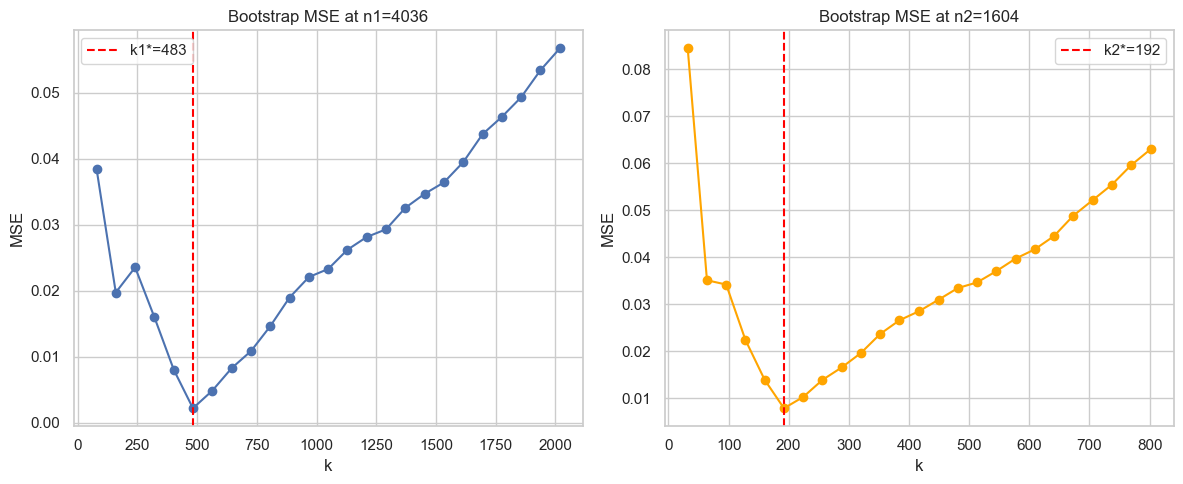

Synthetic validation PASSED: xi recovery within tolerance, exceedance fraction sane.


In [13]:
# ---------------------------------------------------------------------------
# Synthetic validation gate: before trusting danielsson_k0 on the real S&P
# 500 residuals, check it actually works on data with a KNOWN true shape.
# We simulate a light-tailed bulk (normal) below a true threshold and a
# genuine GPD tail above it -- this creates a real bias/variance tradeoff
# (data below the true threshold genuinely violate the GPD approximation),
# unlike pure-GPD synthetic data, which wouldn't test bias-sensitivity at
# all.
# ---------------------------------------------------------------------------

def simulate_contaminated_gpd(n, xi_true, beta_true, frac_tail=0.05, rng=None):
    rng = rng or np.random.default_rng(1)
    n_tail = int(n * frac_tail)
    n_bulk = n - n_tail
    bulk = rng.normal(0, 1, n_bulk)
    u_true = np.quantile(bulk, 1 - frac_tail)
    tail = u_true + genpareto.rvs(c=xi_true, scale=beta_true, size=n_tail, random_state=rng)
    x = np.concatenate([bulk, tail])
    rng.shuffle(x)
    return x, u_true

xi_true, beta_true = 0.25, 1.0
x_sim, u_true = simulate_contaminated_gpd(10154, xi_true, beta_true, rng=np.random.default_rng(42))

res_sim = danielsson_k0(x_sim, n1=int(len(x_sim) ** 0.9), pilot_xi=xi_true,
                         B=300, rng=np.random.default_rng(7))

x_sim_sorted = np.sort(x_sim)[::-1]
u_hat_sim = x_sim_sorted[res_sim["k0"]]
xi_hat_sim, _ = gpd_shape_scale(x_sim_sorted[:res_sim["k0"]] - u_hat_sim)

print(f"True xi = {xi_true}, recovered xi_hat = {xi_hat_sim:.4f}")
print(f"True u (approx) = {u_true:.4f}, selected u = {u_hat_sim:.4f}, "
      f"exceedance frac = {res_sim['k0']/len(x_sim):.4f} (true approx 0.05)")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(res_sim["k_grid_1"], res_sim["mse1"], 'o-')
axs[0].axvline(res_sim["k1_star"], color='red', linestyle='--', label=f"k1*={res_sim['k1_star']}")
axs[0].set(title=f"Bootstrap MSE at n1={res_sim['n1']}", xlabel="k", ylabel="MSE")
axs[0].legend()
axs[1].plot(res_sim["k_grid_2"], res_sim["mse2"], 'o-', color='orange')
axs[1].axvline(res_sim["k2_star"], color='red', linestyle='--', label=f"k2*={res_sim['k2_star']}")
axs[1].set(title=f"Bootstrap MSE at n2={res_sim['n2']}", xlabel="k", ylabel="MSE")
axs[1].legend()
plt.tight_layout()
plt.show()

assert abs(xi_hat_sim - xi_true) < 0.15, "VALIDATION FAILED: xi recovery too far off"
assert 0.01 < res_sim["k0"] / len(x_sim) < 0.20, "VALIDATION FAILED: exceedance fraction insane"
print("Synthetic validation PASSED: xi recovery within tolerance, exceedance fraction sane.")

## Threshold selection: mean-excess and double-bootstrap AMSE

A naive way to estimate the MSE of a tail-index estimator is to bootstrap-resample a given threshold's own exceedances (same sample size, with replacement) and compare each resample's estimate to that same sample's point estimate. That construction only ever measures `Var(xi_hat)`, since a same-size bootstrap is always centered on the full sample's own estimate -- it cannot see bias, which is the other half of the tradeoff threshold selection needs to balance.

Instead, the selector below uses a double-bootstrap AMSE approach, in the spirit of Danielsson, de Haan, Peng, de Vries (2001): subsample *without* replacement at two different sizes `n1` and `n2 = floor(n1²/n)`, and combine the MSE-minimizing order-statistic counts `k1*, k2*` via `k0 = floor(k1*²/k2*)`. This `n1/n2` self-similarity choice algebraically cancels the unknown second-order bias-rate parameter, and is estimator-agnostic (holds for any consistent tail-index estimator, GPD-MLE included, under the same regularity conditions as Hill's estimator).

Danielsson et al.'s original method locates `k1*`/`k2*` via an auxiliary statistic specific to Hill's (log-spacing) estimator, which doesn't have a direct analogue for a GPD-MLE shape estimator. Here, `k1*`/`k2*` are located via **Hall's (1990)** fixed-pilot bootstrap-MSE device, generalized from Hill to GPD-MLE: bootstrap MSE is computed against an independent, external pilot estimate of ξ (the mean-excess shape estimate below, with a Hall-rule `k ≈ 2√n` cross-check printed as a diagnostic), rather than against each subsample's own point estimate. The `n1/n2` combination step is the estimator-agnostic part of the method; the per-size MSE criterion is this implementation's adaptation of it.

Before use on the real residuals, the cell above validates the selector on synthetic data with a **known** true shape parameter -- checking that ξ is recovered within tolerance, the exceedance fraction is sane, and the AMSE(k) curves show genuine interior minima.

# EVT  - Mean excess

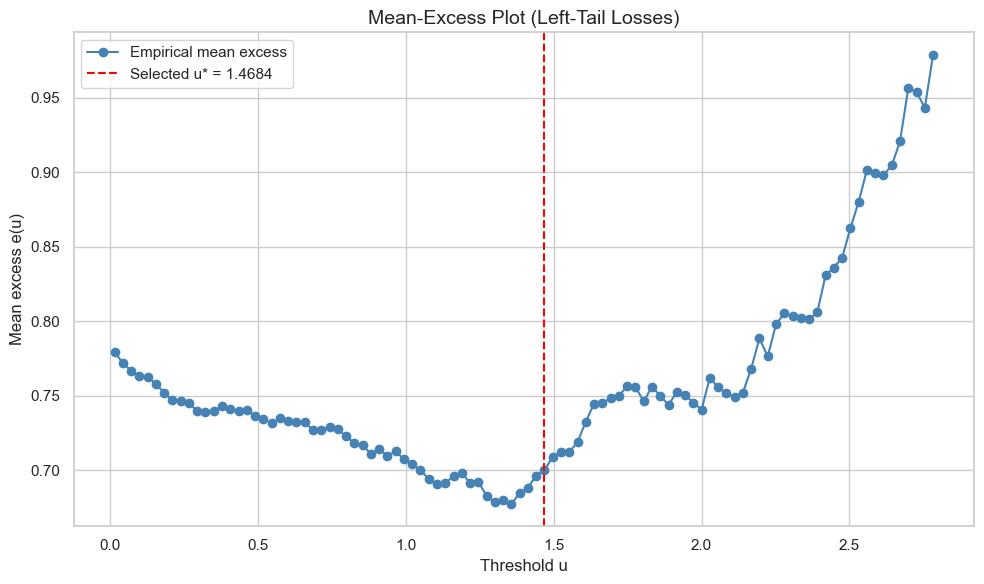

Mean-excess threshold (u): -1.4684
Shape (xi): 0.1422
Scale (beta): 0.5995
Exceedance proportion (q_u): 0.0740 (751 of 10153)


In [14]:
# ---------------------------------------------------------------------------
# Mean-excess-plot threshold selection: find the threshold beyond which the
# empirical mean-excess curve becomes linear, via a two-segment
# (piecewise-linear) changepoint search -- the u_j that minimizes the
# combined SSE of separately fitting a line before u_j and a line after u_j.
# This directly locates the elbow where the curve's behavior changes,
# rather than testing whether the remainder alone looks linear (mean-excess
# curves are often smooth and gently sloped through most of the body of the
# distribution, so a bare "is the remainder linear" test is not
# discriminating enough on its own).
# ---------------------------------------------------------------------------

x_me = data["Residuals"].to_numpy()
n_total = len(x_me)

# Grid extended to the 99th percentile: the mean-excess curve's elbow --
# where it stops declining and turns back up, the classic sign of a heavy
# tail -- can sit past the 90th percentile, so the search window needs to
# reach that far.
u_grid = np.linspace(np.percentile(x_me, 50), np.percentile(x_me, 99), 100)
e_u = np.array([mean_excess(x_me, u) for u in u_grid])
valid = np.isfinite(e_u)
u_grid, e_u = u_grid[valid], e_u[valid]

def two_segment_sse(u, e, j, min_pts=8):
    """Total SSE of fitting two separate lines to (u, e), split at index j."""
    u1, e1, u2, e2 = u[:j], e[:j], u[j:], e[j:]
    if len(u1) < min_pts or len(u2) < min_pts:
        return np.inf
    s1, i1 = np.polyfit(u1, e1, 1)
    s2, i2 = np.polyfit(u2, e2, 1)
    sse1 = np.sum((e1 - (s1 * u1 + i1)) ** 2)
    sse2 = np.sum((e2 - (s2 * u2 + i2)) ** 2)
    return sse1 + sse2

MIN_EXCEEDANCES, MAX_EXCEED_FRAC = 100, 0.15
sse_by_j = np.array([two_segment_sse(u_grid, e_u, j) for j in range(len(u_grid))])
candidates = [j for j in range(len(u_grid))
              if np.isfinite(sse_by_j[j])
              and (x_me > u_grid[j]).sum() >= MIN_EXCEEDANCES
              and (x_me > u_grid[j]).mean() <= MAX_EXCEED_FRAC]
j_star = candidates[int(np.argmin(sse_by_j[candidates]))] if candidates else int(np.nanargmin(sse_by_j))
u_star = u_grid[j_star]

plt.figure(figsize=(10, 6))
plt.plot(u_grid, e_u, 'o-', color='steelblue', label='Empirical mean excess')
plt.axvline(u_star, color='red', linestyle='--', label=f'Selected u* = {u_star:.4f}')
plt.title('Mean-Excess Plot (Left-Tail Losses)', fontsize=14)
plt.xlabel('Threshold u')
plt.ylabel('Mean excess e(u)')
plt.legend()
plt.tight_layout()
plt.show()

exceedances_me = x_me[x_me > u_star] - u_star
xi_meanexcess, beta_meanexcess = gpd_shape_scale(exceedances_me)
threshold_u_meanexcess = -u_star  # back to standardized-residual sign convention
q_u_meanexcess = len(exceedances_me) / n_total

print(f"Mean-excess threshold (u): {threshold_u_meanexcess:.4f}")
print(f"Shape (xi): {xi_meanexcess:.4f}")
print(f"Scale (beta): {beta_meanexcess:.4f}")
print(f"Exceedance proportion (q_u): {q_u_meanexcess:.4f} ({len(exceedances_me)} of {n_total})")

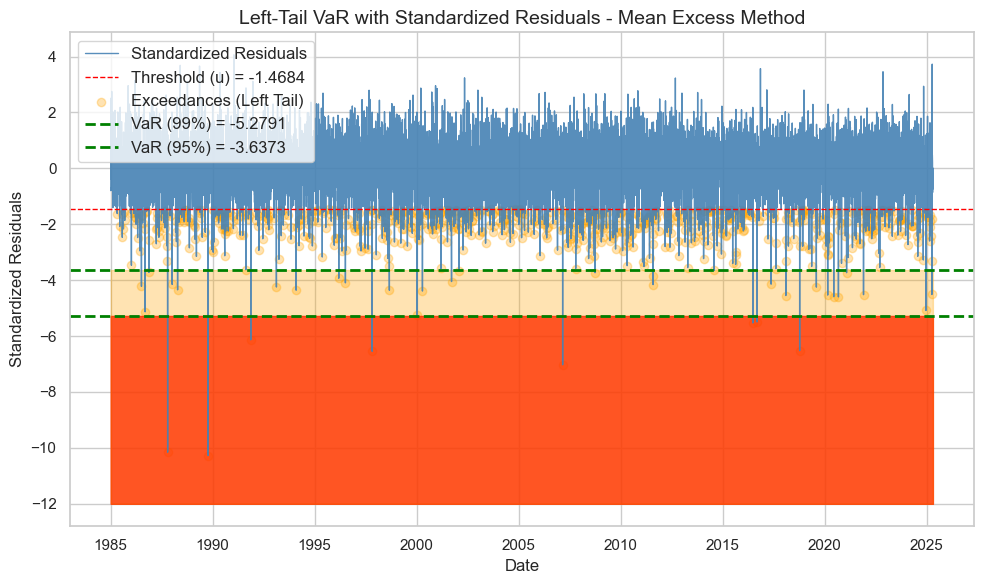

In [15]:
xi_me = xi_meanexcess
beta_me = beta_meanexcess
q_u_me = q_u_meanexcess

z_99_meanexcess = gpd_var(threshold_u_meanexcess, xi_me, beta_me, q_u_me, 0.99)
try:
    z_95_meanexcess = gpd_var(threshold_u_meanexcess, xi_me, beta_me, q_u_me, 0.95)
except ValueError as e:
    print(f"VaR (95%) skipped for the mean-excess threshold: {e}")
    z_95_meanexcess = np.nan

plt.figure(figsize=(10, 6))

plt.plot(data['Date'], standardized_residuals_t, color='steelblue', label='Standardized Residuals', lw=1, alpha=0.9)

plt.axhline(y=threshold_u_meanexcess, color='red', linestyle='--', lw=1, label=f'Threshold (u) = {threshold_u_meanexcess:.4f}')

exceed_points = standardized_residuals_t[standardized_residuals_t < threshold_u_meanexcess]
plt.scatter(data['Date'][standardized_residuals_t < threshold_u_meanexcess], exceed_points, color='orange', label='Exceedances (Left Tail)', alpha=0.3)

plt.axhline(y=z_99_meanexcess, color='green', linestyle='--', lw=2, label=f'VaR (99%) = {z_99_meanexcess:.4f}')
plt.fill_between(data['Date'], y1=z_99_meanexcess, y2=-12, color='red', alpha=0.8)
if np.isfinite(z_95_meanexcess):
    plt.axhline(y=z_95_meanexcess, color='green', linestyle='--', lw=2, label=f'VaR (95%) = {z_95_meanexcess:.4f}')
    plt.fill_between(data['Date'], y1=z_95_meanexcess, y2=-12, color='orange', alpha=0.3)

plt.title('Left-Tail VaR with Standardized Residuals - Mean Excess Method', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Standardized Residuals', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


# Weismann method

Pilot xi (mean-excess) = 0.1422; Hall-rule cross-check (k=202) = 0.3022


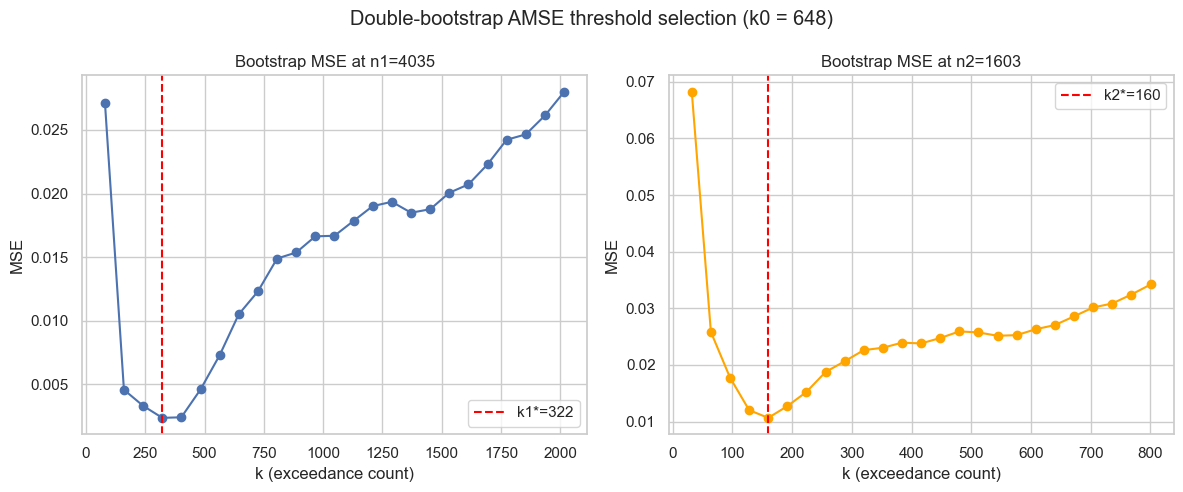

Weissman (double-bootstrap AMSE) threshold (u): -1.5603
Shape (xi): 0.1457
Scale (beta): 0.6078
Exceedance proportion (q_u): 0.0638 (648 of 10153)


In [16]:
# ---------------------------------------------------------------------------
# Weissman-style threshold selection via the double-bootstrap AMSE selector
# defined above.
# ---------------------------------------------------------------------------

x_w = data["Residuals"].to_numpy()
n_total_w = len(x_w)

# Pilot for Hall's device: use the independently-computed mean-excess shape
# estimate (not circular -- it comes from a separately-selected threshold),
# plus a Hall-rule k ~ 2*sqrt(n) cross-check pilot fit directly on the full
# sample, printed as a robustness diagnostic.
pilot_xi = xi_meanexcess
k_pilot_hall = int(round(2 * np.sqrt(n_total_w)))
pilot_xi_hall = gpd_shape_for_k(np.sort(x_w)[::-1], k_pilot_hall)
print(f"Pilot xi (mean-excess) = {pilot_xi:.4f}; Hall-rule cross-check (k={k_pilot_hall}) = {pilot_xi_hall:.4f}")

rng = np.random.default_rng(2312)
result_w = danielsson_k0(x_w, n1=int(n_total_w ** 0.9), pilot_xi=pilot_xi, B=300, rng=rng)
k0 = result_w["k0"]

x_w_sorted = np.sort(x_w)[::-1]
threshold_u_loss = x_w_sorted[k0]
xi_weissman, beta_weissman = gpd_shape_scale(x_w_sorted[:k0] - threshold_u_loss)
threshold_u_weissman = -threshold_u_loss
q_u_weissman = k0 / n_total_w

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(result_w["k_grid_1"], result_w["mse1"], 'o-')
axs[0].axvline(result_w["k1_star"], color='red', linestyle='--', label=f"k1*={result_w['k1_star']}")
axs[0].set(title=f"Bootstrap MSE at n1={result_w['n1']}", xlabel="k (exceedance count)", ylabel="MSE")
axs[0].legend()
axs[1].plot(result_w["k_grid_2"], result_w["mse2"], 'o-', color='orange')
axs[1].axvline(result_w["k2_star"], color='red', linestyle='--', label=f"k2*={result_w['k2_star']}")
axs[1].set(title=f"Bootstrap MSE at n2={result_w['n2']}", xlabel="k (exceedance count)", ylabel="MSE")
axs[1].legend()
plt.suptitle(f"Double-bootstrap AMSE threshold selection (k0 = {k0})")
plt.tight_layout()
plt.show()

print(f"Weissman (double-bootstrap AMSE) threshold (u): {threshold_u_weissman:.4f}")
print(f"Shape (xi): {xi_weissman:.4f}")
print(f"Scale (beta): {beta_weissman:.4f}")
print(f"Exceedance proportion (q_u): {q_u_weissman:.4f} ({k0} of {n_total_w})")

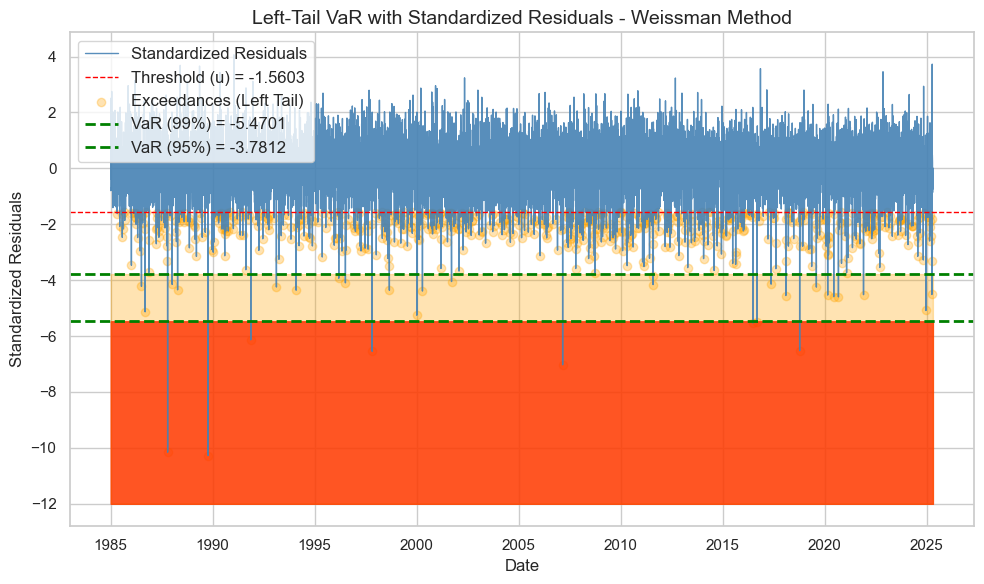

In [17]:
xi_w = xi_weissman
beta_w = beta_weissman
q_u_w = q_u_weissman

z_99_weissman = gpd_var(threshold_u_weissman, xi_w, beta_w, q_u_w, 0.99)
try:
    z_95_weissman = gpd_var(threshold_u_weissman, xi_w, beta_w, q_u_w, 0.95)
except ValueError as e:
    print(f"VaR (95%) skipped for the Weissman threshold: {e}")
    z_95_weissman = np.nan

plt.figure(figsize=(10, 6))

plt.plot(data['Date'], standardized_residuals_t, color='steelblue', label='Standardized Residuals', lw=1, alpha=0.9)

plt.axhline(y=threshold_u_weissman, color='red', linestyle='--', lw=1, label=f'Threshold (u) = {threshold_u_weissman:.4f}')

exceed_points = standardized_residuals_t[standardized_residuals_t < threshold_u_weissman]
plt.scatter(data['Date'][standardized_residuals_t < threshold_u_weissman], exceed_points, color='orange', label='Exceedances (Left Tail)', alpha=0.3)

plt.axhline(y=z_99_weissman, color='green', linestyle='--', lw=2, label=f'VaR (99%) = {z_99_weissman:.4f}')
plt.fill_between(data['Date'], y1=z_99_weissman, y2=-12, color='red', alpha=0.8)
if np.isfinite(z_95_weissman):
    plt.axhline(y=z_95_weissman, color='green', linestyle='--', lw=2, label=f'VaR (95%) = {z_95_weissman:.4f}')
    plt.fill_between(data['Date'], y1=z_95_weissman, y2=-12, color='orange', alpha=0.3)

plt.title('Left-Tail VaR with Standardized Residuals - Weissman Method', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Standardized Residuals', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [18]:
# ---------------------------------------------------------------------------
# Summary: GPD fit and standardized-residual quantiles (z_q) for the three
# threshold-selection methods. z_95 is NaN wherever 1-p exceeds that
# method's own exceedance rate q_u -- see gpd_var() above.
# ---------------------------------------------------------------------------

comparison = pd.DataFrame({
    "Method": ["Preliminary (0.01-quantile)", "Mean-Excess", "Weissman (double-bootstrap AMSE)"],
    "Threshold (u)": [threshold_u_prelim, threshold_u_meanexcess, threshold_u_weissman],
    "Shape (xi)": [xi_prelim, xi_me, xi_w],
    "Scale (beta)": [beta_prelim, beta_me, beta_w],
    "q_u (exceedance proportion)": [q_u_prelim, q_u_me, q_u_w],
    "z_99": [z_99_prelim, z_99_meanexcess, z_99_weissman],
    "z_95": [z_95_prelim, z_95_meanexcess, z_95_weissman],
})

print(comparison.round(4).to_string(index=False))


                          Method  Threshold (u)  Shape (xi)  Scale (beta)  q_u (exceedance proportion)    z_99    z_95
     Preliminary (0.01-quantile)        -2.7831      0.2561        0.7334                       0.0100 -9.2093     NaN
                     Mean-Excess        -1.4684      0.1422        0.5995                       0.0740 -5.2791 -3.6373
Weissman (double-bootstrap AMSE)        -1.5603      0.1457        0.6078                       0.0638 -5.4701 -3.7812


## Devolatilized (return-scale) VaR

`z_99`/`z_95` above are quantiles of the *standardized* residuals, not VaR in actual return units. Converting requires undoing the GARCH standardization:

```
VaR_{t+1}(q) = mu_hat + sigma_hat_{t+1} * z_q
```

Two versions of `sigma_hat` are reported, both computed in `01_time_series_modeling.ipynb` and loaded from `garch_params.csv`:
- **One-step-ahead**: `sigma_hat_next`, the GARCH forecast conditional volatility for the day immediately after the sample ends -- the relevant number for "what's tomorrow's VaR".
- **Average**: `sigma_hat_avg`, the mean of the realized in-sample conditional volatility series -- a smoother, less date-specific figure (see the persistence discussion in notebook 01 for why this is preferred here over the closed-form unconditional-variance formula).

Both are in log-return units (not the `*100`-scaled units GARCH was fit on).

In [19]:
rows = []
for method, z99, z95 in [
    ("Preliminary (0.01-quantile)", z_99_prelim, z_95_prelim),
    ("Mean-Excess", z_99_meanexcess, z_95_meanexcess),
    ("Weissman (double-bootstrap AMSE)", z_99_weissman, z_95_weissman),
]:
    rows.append({
        "Method": method,
        "VaR 99% (one-step-ahead)": devolatilized_var(z99, mu_hat, sigma_hat_next),
        "VaR 95% (one-step-ahead)": devolatilized_var(z95, mu_hat, sigma_hat_next),
        "VaR 99% (average-sigma)": devolatilized_var(z99, mu_hat, sigma_hat_avg),
        "VaR 95% (average-sigma)": devolatilized_var(z95, mu_hat, sigma_hat_avg),
    })
var_return_scale = pd.DataFrame(rows)

print(f"mu_hat = {mu_hat:.6f}, sigma_hat_next = {sigma_hat_next:.6f}, sigma_hat_avg = {sigma_hat_avg:.6f}")
print()
print(var_return_scale.round(4).to_string(index=False))


mu_hat = 0.000764, sigma_hat_next = 0.028456, sigma_hat_avg = 0.010205

                          Method  VaR 99% (one-step-ahead)  VaR 95% (one-step-ahead)  VaR 99% (average-sigma)  VaR 95% (average-sigma)
     Preliminary (0.01-quantile)                   -0.2613                       NaN                  -0.0932                      NaN
                     Mean-Excess                   -0.1495                   -0.1027                  -0.0531                  -0.0364
Weissman (double-bootstrap AMSE)                   -0.1549                   -0.1068                  -0.0551                  -0.0378


## t-distribution consistency check

For GARCH residuals drawn from a Student-t distribution with `nu` degrees of freedom, extreme value theory implies the t-distribution's tail is itself regularly varying with tail index `nu`, so a GPD fit to its extreme left tail should satisfy `xi ~= 1/nu` asymptotically. `nu_hat` comes purely from the GARCH stage (fit to the whole residual distribution); `xi` comes purely from the EVT stage (fit only to the far left tail). Agreement between the two is a genuine cross-check that both stages of the pipeline are telling a consistent story about tail heaviness -- it isn't guaranteed by construction.

In [20]:
xi_from_nu = 1 / nu_hat

ci_low_me, ci_high_me, se_me = gpd_xi_ci(xi_me, len(exceedances_me))
ci_low_w, ci_high_w, se_w = gpd_xi_ci(xi_w, k0)

print(f"t-distribution implied shape: 1/nu_hat = {xi_from_nu:.4f} (nu_hat = {nu_hat:.4f})")
print()
print(f"Mean-Excess:   xi = {xi_me:.4f}, SE = {se_me:.4f}, 95% CI = [{ci_low_me:.4f}, {ci_high_me:.4f}]"
      f" -> 1/nu_hat {'is inside' if ci_low_me <= xi_from_nu <= ci_high_me else 'is NOT inside'} this CI")
print(f"Weissman AMSE: xi = {xi_w:.4f}, SE = {se_w:.4f}, 95% CI = [{ci_low_w:.4f}, {ci_high_w:.4f}]"
      f" -> 1/nu_hat {'is inside' if ci_low_w <= xi_from_nu <= ci_high_w else 'is NOT inside'} this CI")


t-distribution implied shape: 1/nu_hat = 0.1735 (nu_hat = 5.7633)

Mean-Excess:   xi = 0.1422, SE = 0.0417, 95% CI = [0.0605, 0.2239] -> 1/nu_hat is inside this CI
Weissman AMSE: xi = 0.1457, SE = 0.0450, 95% CI = [0.0574, 0.2339] -> 1/nu_hat is inside this CI
